In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

df = pd.read_csv('../data/processed/train_clean.csv')
df.head()

,Survived,Pclass,Sex,SibSp,Parch,Fare,Embarked,Deck,HasCabin,FamilySize,IsAlone,Title,AgeBin,FareBin
0,0,3,male,1,0,7.2500,S,Unknown,0,2,0,Mr,Adulto,Baja
1,1,1,female,1,0,71.2833,C,C,1,2,0,Mrs,Adulto_mayor,MuyAlta
2,1,3,female,0,0,7.9250,S,Unknown,0,1,1,Miss,Adulto,Media
3,1,1,female,1,0,53.1000,S,C,1,2,0,Mrs,Adulto,MuyAlta
4,0,3,male,0,0,8.0500,S,Unknown,0,1,1,Mr,Adulto,Media


In [2]:
# Sex: male/female -> 0/1
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# One-hot encoding de todas las variables categóricas
df = pd.get_dummies(df, columns=['Embarked', 'Title', 'AgeBin', 'FareBin', 'Deck'], drop_first=True)

df.head()

,Survived,Pclass,Sex,SibSp,Parch,Fare,HasCabin,FamilySize,IsAlone,Embarked_Q,...,FareBin_Baja,FareBin_Media,FareBin_MuyAlta,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_Unknown
0,0,3,0,1,0,7.2500,0,2,0,False,...,True,False,False,False,False,False,False,False,False,True
1,1,1,1,1,0,71.2833,1,2,0,False,...,False,False,True,False,True,False,False,False,False,False
2,1,3,1,0,0,7.9250,0,1,1,False,...,False,True,False,False,False,False,False,False,False,True
3,1,1,1,1,0,53.1000,1,2,0,False,...,False,False,True,False,True,False,False,False,False,False
4,0,3,0,0,0,8.0500,0,1,1,False,...,False,True,False,False,False,False,False,False,False,True


In [3]:
X = df.drop(columns=['Survived'])
y = df['Survived']

print(f"Variables predictoras: {list(X.columns)}")
print(f"Forma de X: {X.shape}")

Variables predictoras: ['Pclass', 'Sex', 'SibSp', 'Parch', 'Fare', 'HasCabin', 'FamilySize', 'IsAlone', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'AgeBin_Adulto', 'AgeBin_Adulto_mayor', 'AgeBin_Anciano', 'AgeBin_Niño', 'FareBin_Baja', 'FareBin_Media', 'FareBin_MuyAlta', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_Unknown']
Forma de X: (891, 28)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Entrenamiento: {X_train.shape[0]} pasajeros")
print(f"Prueba: {X_test.shape[0]} pasajeros")

Entrenamiento: 712 pasajeros
Prueba: 179 pasajeros


In [5]:
modelo_lr = LogisticRegression(max_iter=1000)
modelo_lr.fit(X_train, y_train)

y_pred_lr = modelo_lr.predict(X_test)

print("=== Logistic Regression ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.3f}")
print(f"Recall: {recall_score(y_test, y_pred_lr):.3f}")
print(f"F1-score: {f1_score(y_test, y_pred_lr):.3f}")

=== Logistic Regression ===
Accuracy: 0.827
Precision: 0.779
Recall: 0.768
F1-score: 0.774


In [6]:
# Comparar accuracy en TRAIN vs TEST para Logistic Regression
train_acc_lr = accuracy_score(y_train, modelo_lr.predict(X_train))
test_acc_lr = accuracy_score(y_test, modelo_lr.predict(X_test))

print("=== Logistic Regression ===")
print(f"Accuracy en TRAIN: {train_acc_lr:.3f}")
print(f"Accuracy en TEST:  {test_acc_lr:.3f}")
print(f"Diferencia: {train_acc_lr - test_acc_lr:.3f}")

=== Logistic Regression ===
Accuracy en TRAIN: 0.827
Accuracy en TEST:  0.827
Diferencia: 0.000


In [7]:
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)

y_pred_rf = modelo_rf.predict(X_test)

print("=== Random Forest ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.3f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.3f}")
print(f"F1-score: {f1_score(y_test, y_pred_rf):.3f}")

=== Random Forest ===
Accuracy: 0.777
Precision: 0.730
Recall: 0.667
F1-score: 0.697


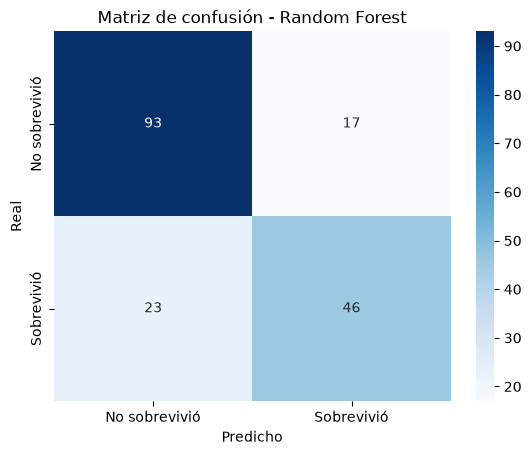

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No sobrevivió', 'Sobrevivió'],
            yticklabels=['No sobrevivió', 'Sobrevivió'])
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.title('Matriz de confusión - Random Forest')
plt.show()

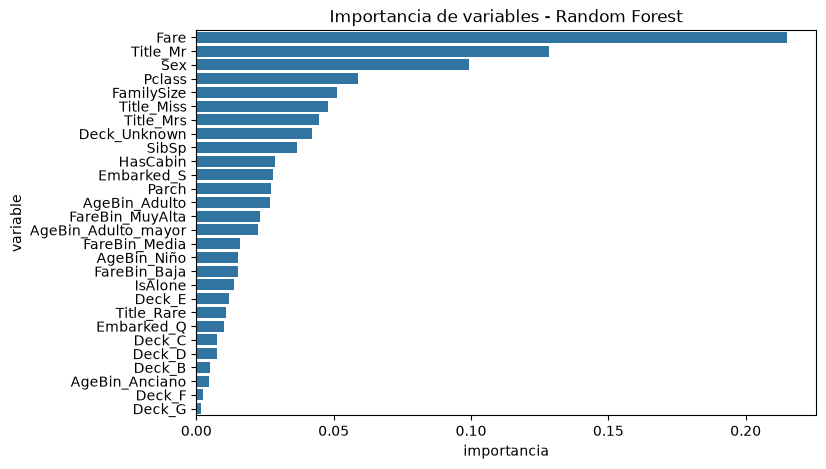

In [9]:
importancias = pd.DataFrame({
    'variable': X.columns,
    'importancia': modelo_rf.feature_importances_
}).sort_values('importancia', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=importancias, x='importancia', y='variable')
plt.title('Importancia de variables - Random Forest')
plt.show()

In [10]:
from sklearn.model_selection import cross_val_score

# Comparamos performance en distintos splits del dataset
scores_rf = cross_val_score(modelo_rf, X_train, y_train, cv=5, scoring='accuracy')

print(f"Accuracy en cada fold: {scores_rf}")
print(f"Promedio: {scores_rf.mean():.3f} (+/- {scores_rf.std():.3f})")

Accuracy en cada fold: [0.7972028  0.76923077 0.80985915 0.83802817 0.78873239]
Promedio: 0.801 (+/- 0.023)


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"Mejores parámetros: {grid_search.best_params_}")
print(f"Mejor accuracy (cross-val): {grid_search.best_score_:.3f}")

mejor_rf = grid_search.best_estimator_

Mejores parámetros: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Mejor accuracy (cross-val): 0.829


In [ ]:
# Comparar accuracy en TRAIN vs TEST para detectar overfitting

# Random Forest default
train_acc_rf = accuracy_score(y_train, modelo_rf.predict(X_train))
test_acc_rf = accuracy_score(y_test, modelo_rf.predict(X_test))

print("=== Random Forest (default) ===")
print(f"Accuracy en TRAIN: {train_acc_rf:.3f}")
print(f"Accuracy en TEST:  {test_acc_rf:.3f}")
print(f"Diferencia: {train_acc_rf - test_acc_rf:.3f}")
print()

# Random Forest optimizado
train_acc_mejor = accuracy_score(y_train, mejor_rf.predict(X_train))
test_acc_mejor = accuracy_score(y_test, mejor_rf.predict(X_test))

print("=== Random Forest (optimizado) ===")
print(f"Accuracy en TRAIN: {train_acc_mejor:.3f}")
print(f"Accuracy en TEST:  {test_acc_mejor:.3f}")
print(f"Diferencia: {train_acc_mejor - test_acc_mejor:.3f}")

=== Random Forest (default) ===
Accuracy en TRAIN: 0.955
Accuracy en TEST:  0.777
Diferencia: 0.179

=== Random Forest (optimizado) ===
Accuracy en TRAIN: 0.900
Accuracy en TEST:  0.799
Diferencia: 0.101


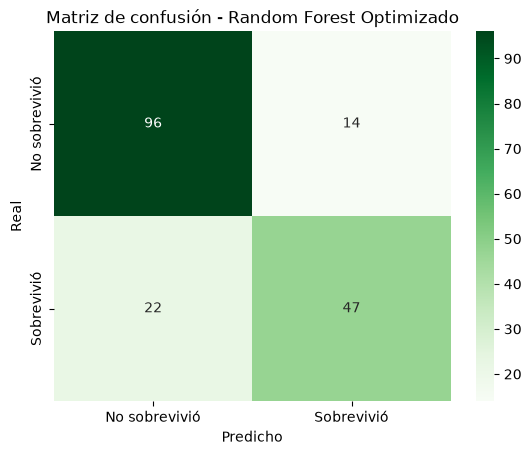

In [ ]:
# Predicciones del Random Forest optimizado
y_pred_mejor_rf = mejor_rf.predict(X_test)

# Matriz de confusión - Random Forest optimizado
cm_mejor = confusion_matrix(y_test, y_pred_mejor_rf)
sns.heatmap(cm_mejor, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['No sobrevivió', 'Sobrevivió'],
            yticklabels=['No sobrevivió', 'Sobrevivió'])
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.title('Matriz de confusión - Random Forest Optimizado')
plt.show()

In [ ]:
# buscamos las depth al rededor de "5"
from sklearn.model_selection import GridSearchCV

param_grid_v2 = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 5, 6, 7, 8],
    'min_samples_split': [5, 10, 15],
    'min_samples_leaf': [2, 4, 6],
    'max_features': ['sqrt', 'log2']
}

grid_search_v2 = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_v2,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_v2.fit(X_train, y_train)

print(f"Mejores parámetros (v2): {grid_search_v2.best_params_}")
print(f"Mejor accuracy (cross-val) (v2): {grid_search_v2.best_score_:.3f}")

mejor_rf_v2 = grid_search_v2.best_estimator_

Mejores parámetros (v2): {'max_depth': 8, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Mejor accuracy (cross-val) (v2): 0.827


In [ ]:
print("=== Comparación GridSearch v1 vs v2 ===")
print(f"v1 - Mejor accuracy (cross-val): {grid_search.best_score_:.3f}")
print(f"v2 - Mejor accuracy (cross-val): {grid_search_v2.best_score_:.3f}")
print()
print(f"v1 - Test accuracy: {accuracy_score(y_test, mejor_rf.predict(X_test)):.3f}")
print(f"v2 - Test accuracy: {accuracy_score(y_test, mejor_rf_v2.predict(X_test)):.3f}")

=== Comparación GridSearch v1 vs v2 ===
v1 - Mejor accuracy (cross-val): 0.829
v2 - Mejor accuracy (cross-val): 0.827

v1 - Test accuracy: 0.799
v2 - Test accuracy: 0.793


In [ ]:
# gradiante Boosting 
from sklearn.ensemble import GradientBoostingClassifier

modelo_gb = GradientBoostingClassifier(random_state=42)
modelo_gb.fit(X_train, y_train)
y_pred_gb = modelo_gb.predict(X_test)

print("=== Gradient Boosting ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_gb):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_gb):.3f}")
print(f"Recall: {recall_score(y_test, y_pred_gb):.3f}")
print(f"F1-score: {f1_score(y_test, y_pred_gb):.3f}")

=== Gradient Boosting ===
Accuracy: 0.810
Precision: 0.778
Recall: 0.710
F1-score: 0.742


In [ ]:
train_acc_gb = accuracy_score(y_train, modelo_gb.predict(X_train))
test_acc_gb = accuracy_score(y_test, modelo_gb.predict(X_test))

print("=== Gradient Boosting - Train vs Test ===")
print(f"Accuracy en TRAIN: {train_acc_gb:.3f}")
print(f"Accuracy en TEST:  {test_acc_gb:.3f}")
print(f"Diferencia: {train_acc_gb - test_acc_gb:.3f}")

=== Gradient Boosting - Train vs Test ===
Accuracy en TRAIN: 0.904
Accuracy en TEST:  0.810
Diferencia: 0.094


In [ ]:
param_grid_gb = {
    'n_estimators': [100, 200],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.01, 0.05, 0.1],
    'min_samples_leaf': [2, 4, 6]
}

grid_search_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_gb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_gb.fit(X_train, y_train)

print(f"Mejores parámetros (GB): {grid_search_gb.best_params_}")
print(f"Mejor accuracy (cross-val) (GB): {grid_search_gb.best_score_:.3f}")

mejor_gb = grid_search_gb.best_estimator_

Mejores parámetros (GB): {'learning_rate': 0.1, 'max_depth': 2, 'min_samples_leaf': 6, 'n_estimators': 200}
Mejor accuracy (cross-val) (GB): 0.836


In [ ]:
y_pred_mejor_gb = mejor_gb.predict(X_test)

print("=== Gradient Boosting Optimizado ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_mejor_gb):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_mejor_gb):.3f}")
print(f"Recall: {recall_score(y_test, y_pred_mejor_gb):.3f}")
print(f"F1-score: {f1_score(y_test, y_pred_mejor_gb):.3f}")

=== Gradient Boosting Optimizado ===
Accuracy: 0.827
Precision: 0.797
Recall: 0.739
F1-score: 0.767


In [ ]:
train_acc_mejor_gb = accuracy_score(y_train, mejor_gb.predict(X_train))
test_acc_mejor_gb = accuracy_score(y_test, mejor_gb.predict(X_test))

print("=== Gradient Boosting Optimizado - Train vs Test ===")
print(f"Accuracy en TRAIN: {train_acc_mejor_gb:.3f}")
print(f"Accuracy en TEST:  {test_acc_mejor_gb:.3f}")
print(f"Diferencia: {train_acc_mejor_gb - test_acc_mejor_gb:.3f}")

=== Gradient Boosting Optimizado - Train vs Test ===
Accuracy en TRAIN: 0.883
Accuracy en TEST:  0.827
Diferencia: 0.057


In [ ]:
# Cargar el dataset de test de Kaggle
df_test = pd.read_csv('../data/test.csv')

# Guardar PassengerId aparte (lo necesitas para el archivo de envío)
passenger_ids = df_test['PassengerId']

# HasCabin
df_test['HasCabin'] = df_test['Cabin'].notnull().astype(int)
df_test = df_test.drop(columns=['Cabin'])

# Age: mediana por Pclass y Sex
df_test['Age'] = df_test.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))

# Embarked: moda
df_test['Embarked'] = df_test['Embarked'].fillna(df_test['Embarked'].mode()[0])

# Fare: test.csv puede tener 1 nulo (train no tenía)
df_test['Fare'] = df_test['Fare'].fillna(df_test['Fare'].median())

# FamilySize e IsAlone
df_test['FamilySize'] = df_test['SibSp'] + df_test['Parch'] + 1
df_test['IsAlone'] = (df_test['FamilySize'] == 1).astype(int)

# Title
df_test['Title'] = df_test['Name'].str.extract(r',\s*([^\.]+)\.')
title_map = {
    'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master',
    'Dr': 'Rare', 'Rev': 'Rare', 'Col': 'Rare', 'Major': 'Rare',
    'Mlle': 'Miss', 'Countess': 'Rare', 'Ms': 'Miss', 'Lady': 'Rare',
    'Jonkheer': 'Rare', 'Don': 'Rare', 'Dona': 'Rare', 'Capt': 'Rare', 'Sir': 'Rare'
}
df_test['Title'] = df_test['Title'].map(title_map)
df_test['Title'] = df_test['Title'].fillna('Rare')

# AgeBin y FareBin (mismos cortes que en train)
df_test['AgeBin'] = pd.cut(df_test['Age'], bins=[0, 12, 18, 35, 60, 100], labels=['Niño', 'Adolescente', 'Adulto', 'Adulto_mayor', 'Anciano'])
df_test['FareBin'] = pd.qcut(df_test['Fare'], 4, labels=['Baja', 'Media', 'Alta', 'MuyAlta'])

# Eliminar columnas no usadas
df_test = df_test.drop(columns=['Name', 'Ticket', 'PassengerId'])

df_test.isnull().sum()

Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked      0
HasCabin      0
FamilySize    0
IsAlone       0
Title         0
AgeBin        0
FareBin       0
dtype: int64

In [ ]:
# Sex: male/female -> 0/1
df_test['Sex'] = df_test['Sex'].map({'male': 0, 'female': 1})

# One-hot encoding de las mismas variables categóricas que usaste en train
df_test = pd.get_dummies(df_test, columns=['Embarked', 'Title', 'AgeBin', 'FareBin'], drop_first=True)

df_test.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,HasCabin,FamilySize,IsAlone,Embarked_Q,...,Title_Mr,Title_Mrs,Title_Rare,AgeBin_Adolescente,AgeBin_Adulto,AgeBin_Adulto_mayor,AgeBin_Anciano,FareBin_Media,FareBin_Alta,FareBin_MuyAlta
0,3,0,34.5,0,0,7.8292,0,1,1,True,...,True,False,False,False,True,False,False,False,False,False
1,3,1,47.0,1,0,7.0000,0,2,0,False,...,False,True,False,False,False,True,False,False,False,False
2,2,0,62.0,0,0,9.6875,0,1,1,True,...,True,False,False,False,False,False,True,True,False,False
3,3,0,27.0,0,0,8.6625,0,1,1,False,...,True,False,False,False,True,False,False,True,False,False
4,3,1,22.0,1,1,12.2875,0,3,0,False,...,False,True,False,False,True,False,False,True,False,False


In [ ]:
# Asegurar que df_test tenga EXACTAMENTE las mismas columnas que X (en el mismo orden)
df_test = df_test.reindex(columns=X.columns, fill_value=0)

print(f"Columnas en X (train): {list(X.columns)}")
print(f"Columnas en df_test: {list(df_test.columns)}")
print(f"¿Coinciden?: {list(X.columns) == list(df_test.columns)}")

Columnas en X (train): ['Pclass', 'Sex', 'SibSp', 'Parch', 'Fare', 'HasCabin', 'FamilySize', 'IsAlone', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'AgeBin_Adulto', 'AgeBin_Adulto_mayor', 'AgeBin_Anciano', 'AgeBin_Niño', 'FareBin_Baja', 'FareBin_Media', 'FareBin_MuyAlta', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_Unknown']
Columnas en df_test: ['Pclass', 'Sex', 'SibSp', 'Parch', 'Fare', 'HasCabin', 'FamilySize', 'IsAlone', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'AgeBin_Adulto', 'AgeBin_Adulto_mayor', 'AgeBin_Anciano', 'AgeBin_Niño', 'FareBin_Baja', 'FareBin_Media', 'FareBin_MuyAlta', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_Unknown']
¿Coinciden?: True


In [ ]:
predicciones = modelo_lr.predict(df_test)

# Armar el archivo final en el formato que pide Kaggle
submission = pd.DataFrame({
    'PassengerId': passenger_ids,
    'Survived': predicciones
})

submission.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [ ]:
submission.to_csv('../outputs/prediccion_final.csv', index=False)
print("Archivo de predicción guardado correctamente ✅")

Archivo de predicción guardado correctamente ✅


In [ ]:
predicciones_rf = mejor_rf.predict(df_test)

# Armar el archivo de envío
submission_rf = pd.DataFrame({
    'PassengerId': passenger_ids,
    'Survived': predicciones_rf
})

submission_rf.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


In [ ]:
submission_rf.to_csv('../outputs/prediccion_rf.csv', index=False)
print("Archivo de predicción (Random Forest) guardado correctamente ✅")

Archivo de predicción (Random Forest) guardado correctamente ✅


In [11]:
modelo_lr_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')
modelo_lr_balanced.fit(X_train, y_train)
y_pred_balanced = modelo_lr_balanced.predict(X_test)

print("=== Logistic Regression (balanced) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_balanced):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_balanced):.3f}")
print(f"Recall: {recall_score(y_test, y_pred_balanced):.3f}")
print(f"F1-score: {f1_score(y_test, y_pred_balanced):.3f}")

=== Logistic Regression (balanced) ===
Accuracy: 0.816
Precision: 0.737
Recall: 0.812
F1-score: 0.772


In [12]:
modelo_rf_balanced = RandomForestClassifier(random_state=42, class_weight='balanced')
modelo_rf_balanced.fit(X_train, y_train)
y_pred_rf_balanced = modelo_rf_balanced.predict(X_test)

print("=== Random Forest (balanced) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf_balanced):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_rf_balanced):.3f}")
print(f"Recall: {recall_score(y_test, y_pred_rf_balanced):.3f}")
print(f"F1-score: {f1_score(y_test, y_pred_rf_balanced):.3f}")

=== Random Forest (balanced) ===
Accuracy: 0.788
Precision: 0.707
Recall: 0.768
F1-score: 0.736


In [13]:
# GridSearchCV para Random Forest con class_weight='balanced'
param_grid_balanced = {
    'n_estimators': [100, 200, 300],
    'max_depth': [6, 8, 10, 12, None],
    'min_samples_split': [5, 10, 15],
    'min_samples_leaf': [2, 4, 6],
    'max_features': ['sqrt', 'log2']
}

grid_search_balanced = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid_balanced,
    cv=5,
    scoring='accuracy',  # sigue usando accuracy como criterio de selección
    n_jobs=-1
)

grid_search_balanced.fit(X_train, y_train)

print(f"Mejores parámetros (balanced): {grid_search_balanced.best_params_}")
print(f"Mejor accuracy (cross-val) (balanced): {grid_search_balanced.best_score_:.3f}")

mejor_rf_balanced = grid_search_balanced.best_estimator_

NameError: name 'GridSearchCV' is not defined